<a href="https://colab.research.google.com/github/jajajandro/LIP_updated-codes/blob/main/Copia_de_to_df.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
!pip install uproot
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import awkward as ak

In [22]:
# Get the data
from google.colab import drive
drive.mount('/content/drive')
! mkdir -p /content/drive/MyDrive/LIP_internships26_SNDNue/
! wget -N https://cristova.web.cern.ch/cristova/share/LIP_Internships/snd_0mu_summaryTree_nu_2022_noMCEB_final_withlumiscaling.root -P /content/drive/MyDrive/LIP_internships26_SNDNue/
! wget -N https://cristova.web.cern.ch/cristova/share/LIP_Internships/snd_0mu_summaryTree_nu_2024_noMCEB_final_withlumiscaling.root -P /content/drive/MyDrive/LIP_internships26_SNDNue/

! ls /content/drive/MyDrive/LIP_internships26_SNDNue/

data_path = "/content/drive/MyDrive/LIP_internships26_SNDNue/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--2026-07-17 10:59:00--  https://cristova.web.cern.ch/cristova/share/LIP_Internships/snd_0mu_summaryTree_nu_2022_noMCEB_final_withlumiscaling.root
Resolving cristova.web.cern.ch (cristova.web.cern.ch)... 188.184.111.229, 188.184.96.45, 137.138.55.232, ...
Connecting to cristova.web.cern.ch (cristova.web.cern.ch)|188.184.111.229|:443... connected.
HTTP request sent, awaiting response... 304 Not Modified
File ‘/content/drive/MyDrive/LIP_internships26_SNDNue/snd_0mu_summaryTree_nu_2022_noMCEB_final_withlumiscaling.root’ not modified on server. Omitting download.

--2026-07-17 10:59:01--  https://cristova.web.cern.ch/cristova/share/LIP_Internships/snd_0mu_summaryTree_nu_2024_noMCEB_final_withlumiscaling.root
Resolving cristova.web.cern.ch (cristova.web.cern.ch)... 188.184.111.229, 188.184.96.45, 137.138.55.232, ...
Connecting to cristova.web.cern.ch (cristova.web

In [23]:
data_path = "/content/drive/MyDrive/LIP_internships26_SNDNue/" # Redefine data_path with the correct path
data = uproot.concatenate([data_path+"snd_0mu_summaryTree_nu_2022_noMCEB_final_withlumiscaling.root:snd_0mu_summaryTree",
                           data_path+"snd_0mu_summaryTree_nu_2024_noMCEB_final_withlumiscaling.root:snd_0mu_summaryTree"])
df = ak.to_dataframe(data)

In [24]:
signal_df = df[np.logical_and(np.abs(df['pdg']) == 12, df['cc'])]
background_df = df[np.logical_or(np.abs(df['pdg']) != 12, df['cc'] == False)]

In [25]:
signal_df["target"] = 1.
background_df["target"] = 0.

/tmp/ipykernel_828/1338080863.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  signal_df["target"] = 1.
/tmp/ipykernel_828/1338080863.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  background_df["target"] = 0.


In [26]:
signal_df.to_csv(data_path+"signal.csv", index=False)
background_df.to_csv(data_path+"background.csv", index=False)

/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:7093: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)
/tmp/ipykernel_828/2242031114.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()
/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


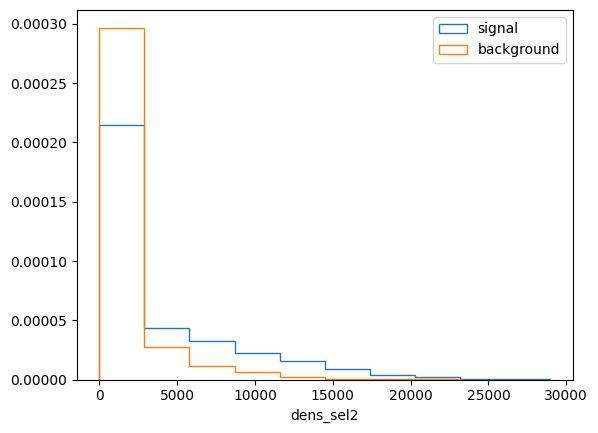

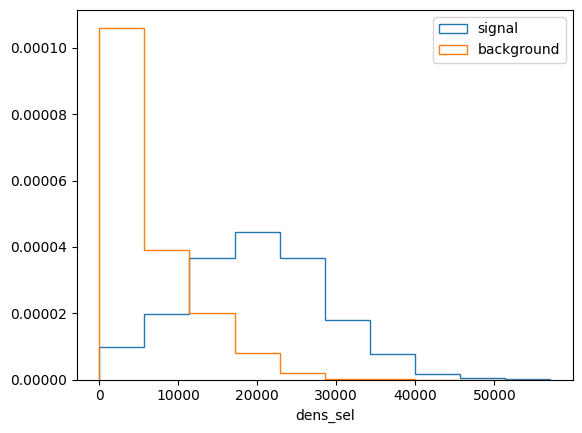

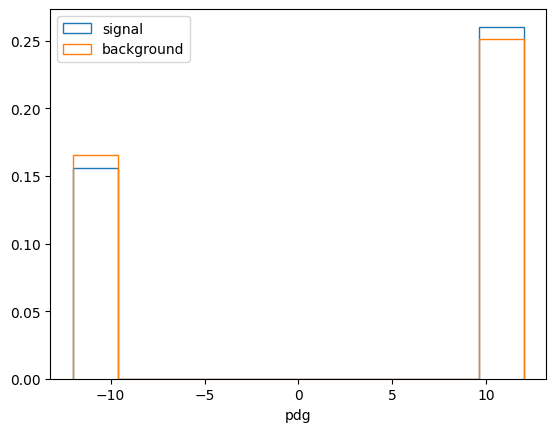

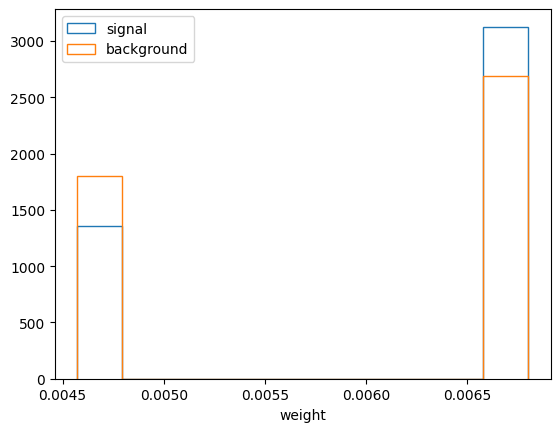

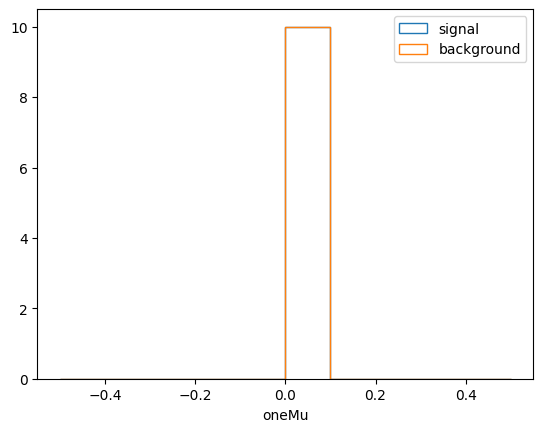

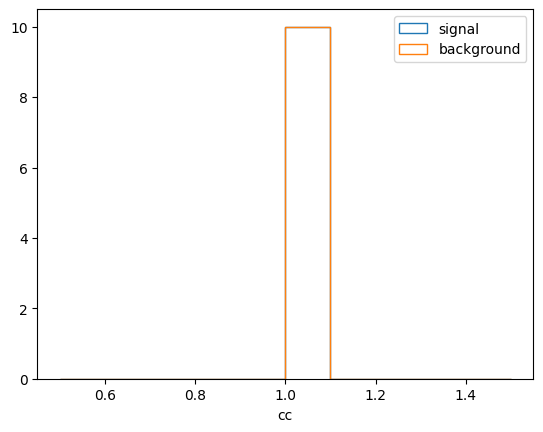

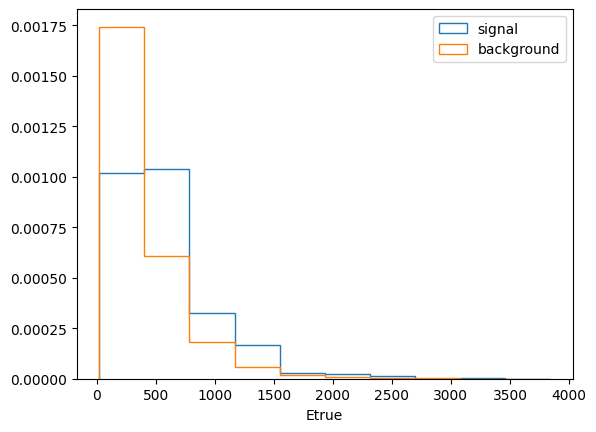

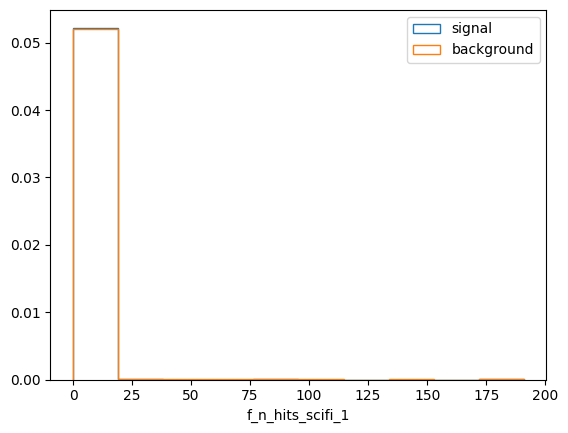

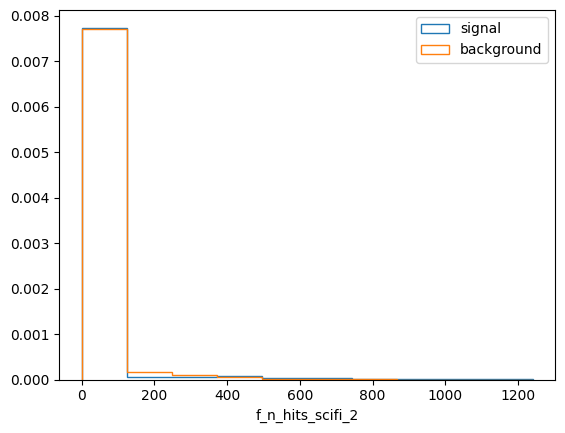

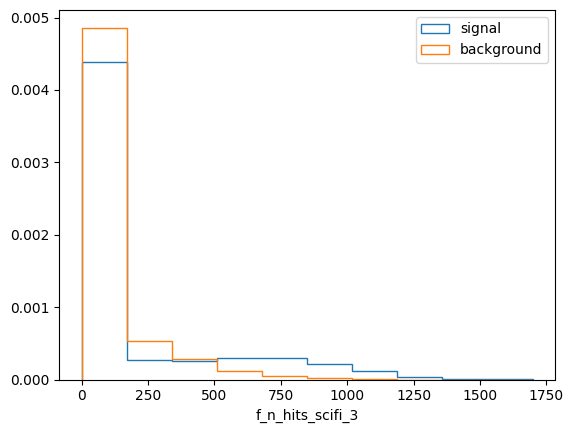

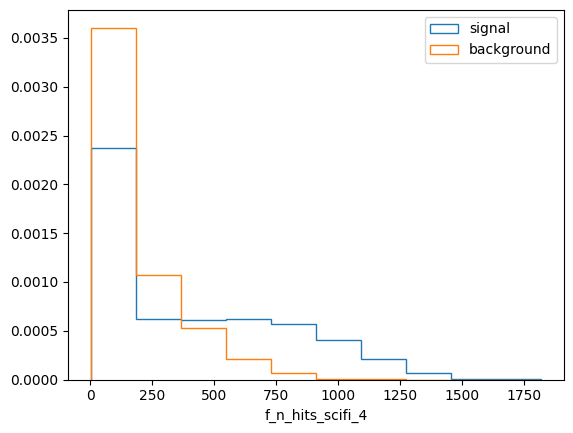

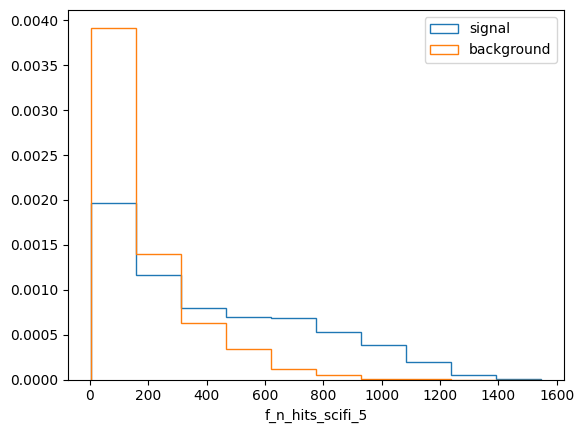

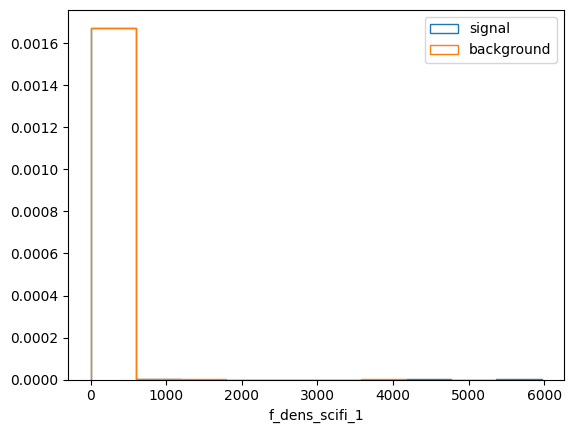

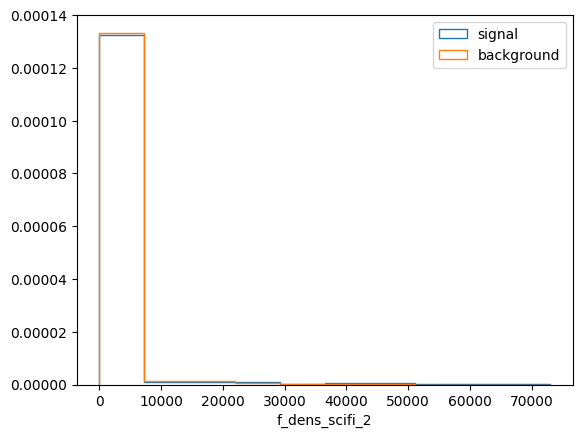

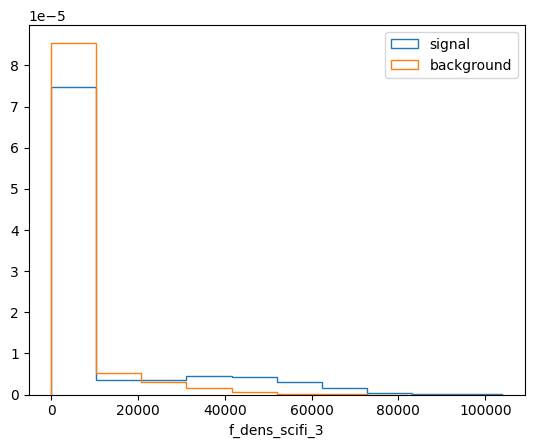

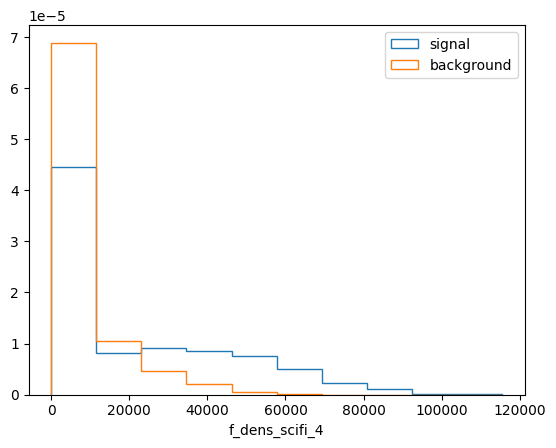

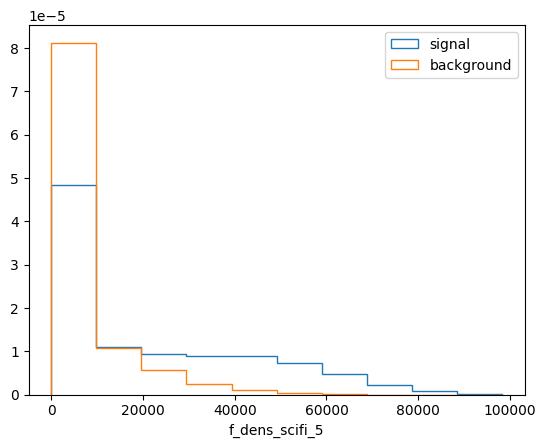

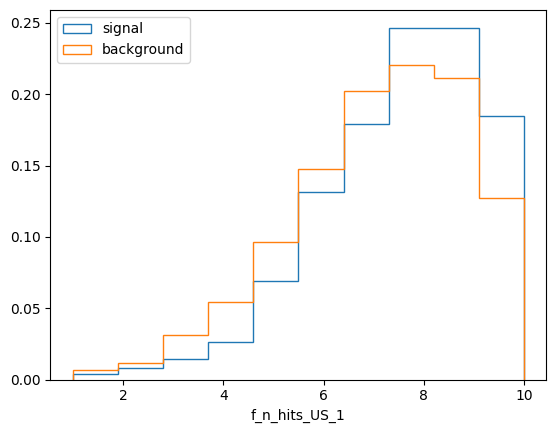

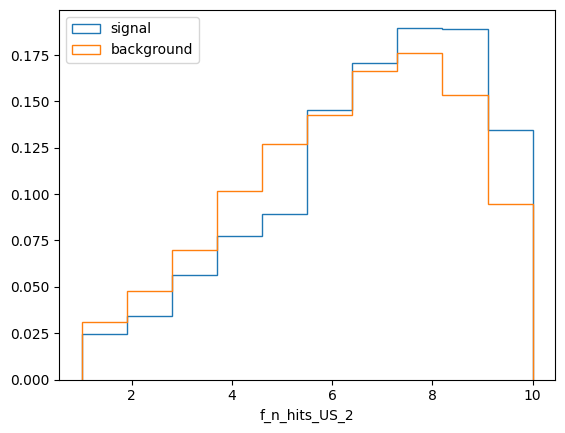

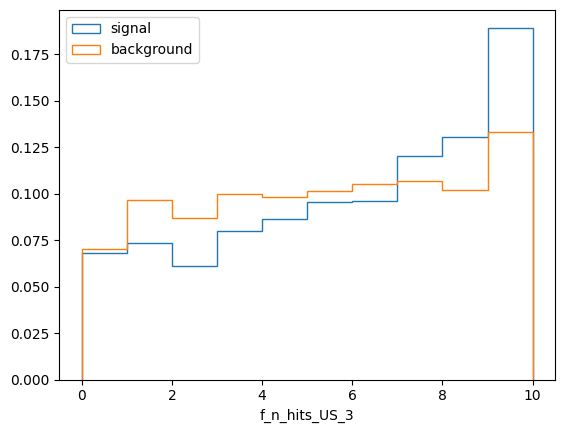

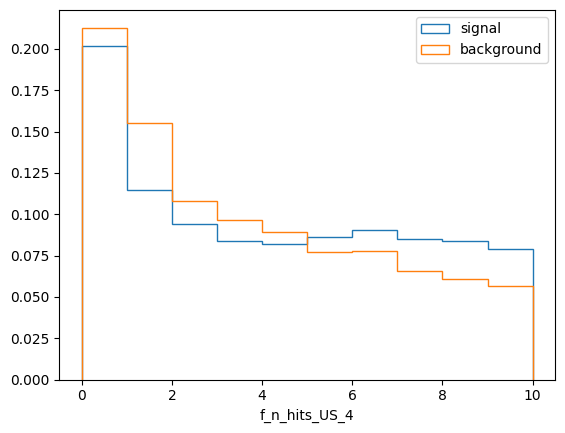

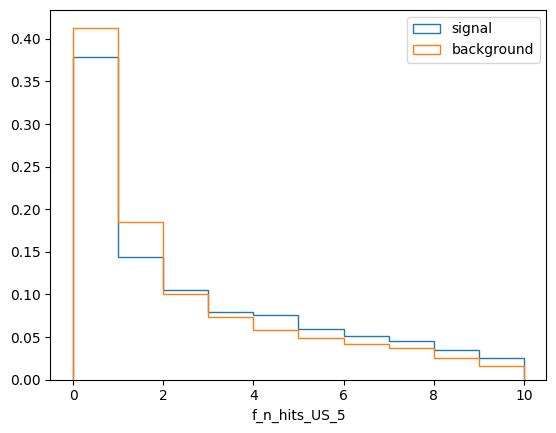

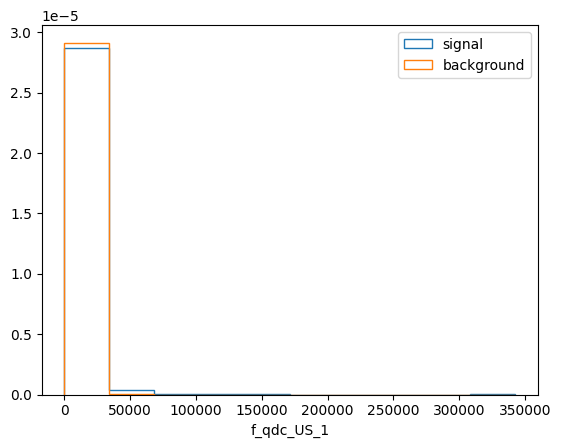

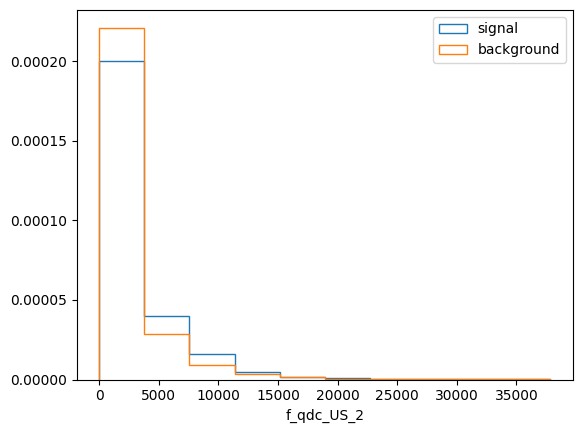

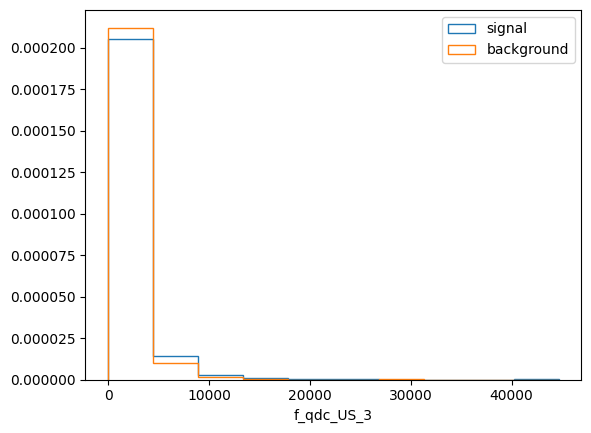

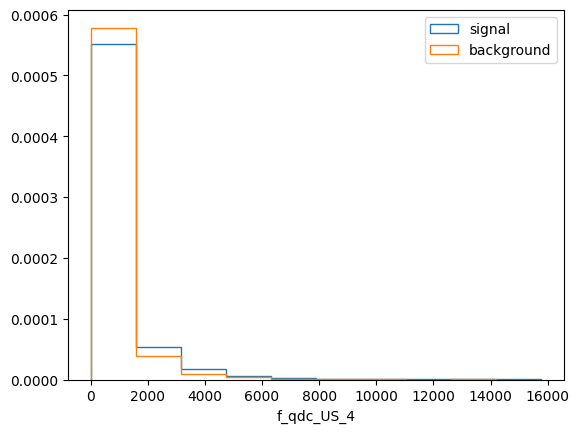

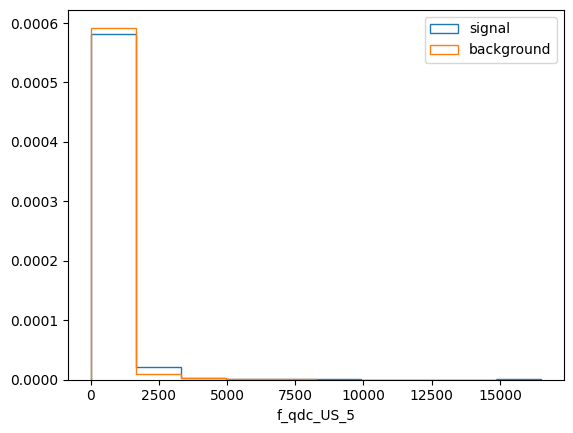

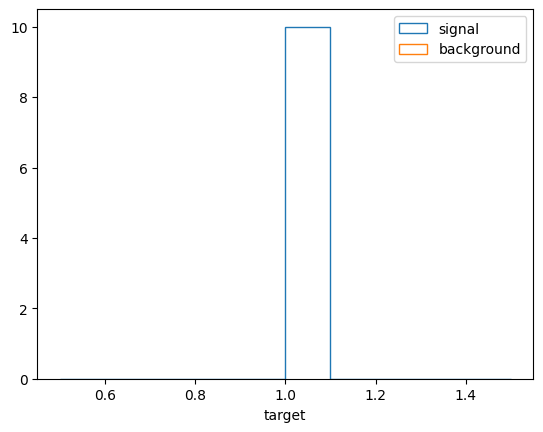

In [27]:
for k in signal_df.keys():
  plt.figure()
  h, bins, _ = plt.hist(signal_df[k], histtype = "step", density = True, label = "signal")
  plt.hist(background_df[k], bins = bins, histtype = "step", density = True, label = "background")
  plt.legend()
  plt.xlabel(k)